# 03 — Model Extension: comparing candidate model families

This is **Step 2** of the roadmap in `process_visualisation.ipynb` (Diagram B): apply the exact
same setup — same cleaned features, same preprocessing, same cross-validation scheme — to
several candidate model families, compare them on PR-AUC, and see which one earns the right to
be tuned in a future Step 3. No hyperparameter tuning, no feature selection, no resampling here —
same rule as `02_baseline_model.ipynb`'s baseline: cross-validation measures these models
honestly, it doesn't optimize them.

Candidates, alongside the `02_baseline_model.ipynb` logistic regression baseline:

- **Random Forest** — captures non-linear effects/interactions; imbalance handling via
  `class_weight="balanced"`, same lever as the baseline.
- **KNN** — a genuinely different bet: distance-based, no native `class_weight` option at all
  (flagged explicitly below — this is expected to hurt it on a ~5.6%-imbalanced dataset, not a
  bug).
- **XGBoost** — a new dependency for this project (not used in `01`/`02`); imbalance handling
  via `scale_pos_weight`, XGBoost's equivalent of `class_weight`.
- **LightGBM** — added on top of the original four: the actual model family the real 4th-place
  Zindi solution used (`00_project_plan.md` §4.4), with `class_weight="balanced"` like Random
  Forest. Run through the same one-hot-encoded pipeline as everything else here for a fair,
  apples-to-apples comparison -- LightGBM's native categorical handling (no one-hot needed) is a
  real optimization it's *not* getting in this pass, worth trying separately later.
- **Isolation Forest** — unsupervised anomaly detection; fits *without* using `target` at all,
  wrapped in a small adapter so it can run through the identical pipeline/CV machinery as the
  other four (see Step 3). A different bet than the other three, not held to the same bar.

## Imports and constants

In [135]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from dotenv import load_dotenv

load_dotenv()  # 01_eda uses .env when generating the CSVs; this notebook only reads them.

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
TRAINING_FEATURES_PATH = PROCESSED_DIR / "df_training.csv"

RSEED = 42  # same seed 01_eda.ipynb / 02_baseline_model.ipynb use
N_SPLITS = 5

# Reference numbers from 02_baseline_model.ipynb -- not re-computed here, just cited.
DUMMY_AVERAGE_PRECISION = 0.056092
DUMMY_ROC_AUC = 0.501831

if not TRAINING_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAINING_FEATURES_PATH}. Run 01_eda.ipynb with SAVE_TRAINING_ARTIFACTS=true first "
        "to produce the cleaned, client-level feature table this notebook loads."
    )

## Step 1 — Load the cleaned, client-level features

This notebook is read-only: it loads the CSVs created by `01_eda.ipynb`. The `.env` setting `SAVE_TRAINING_ARTIFACTS=true` is used when running the EDA save cell; it does not create or overwrite data here. Run `01_eda.ipynb` with that setting before starting this notebook.

In [136]:
df = pd.read_csv(TRAINING_FEATURES_PATH)
df["client_id"] = df["client_id"].astype("string")
df["target"] = df["target"].astype("int8")

# These are the exact 15 inputs selected in 01_eda and used by 02_baseline_model.
expected_columns = {
    "client_id", "target",
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
    "client_catg", "disrict", "region",
}
missing_columns = sorted(expected_columns - set(df.columns))
if missing_columns:
    raise ValueError(f"{TRAINING_FEATURES_PATH} is missing required baseline columns: {missing_columns}")

overview = pd.DataFrame({
    "rows": [len(df)],
    "unique_clients": [df["client_id"].nunique()],
    "fraud_rate": [df["target"].mean()],
})
display(overview)

,rows,unique_clients,fraud_rate
0,135493,135493,0.055841


## Step 2 — Preprocessing (identical to `02_baseline_model.ipynb`)

The CSV contains the 15 client-level inputs selected in the EDA. Raw `creation_date`, `first_invoice`, and `last_invoice` are intentionally not saved in this modelling table, so this notebook does not parse them. We use the same 12 numeric features, 3 categorical features, median imputation, scaling, and one-hot encoding as the baseline.

The preprocessing is duplicated here so this notebook can run on its own, but the feature lists and transformations stay aligned with `02_baseline_model.ipynb`.

In [137]:
categorical_features = ["client_catg", "region", "disrict"]
numeric_features = [
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
]
model_features = numeric_features + categorical_features

X = df[model_features]
y = df["target"]

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

base_rate = y.mean()
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RSEED)

## Step 3 — Define the candidate models

`IsolationForestAnomalyScorer` is a small adapter, not a new algorithm: `IsolationForest` fits
without looking at `target` at all (unsupervised) and its native score runs the *opposite*
direction of every other model here (low score = anomaly). The wrapper fits it as usual, then
negates its anomaly score so "higher = more likely fraud" holds for every model in this
notebook — the only way to legitimately drop it into the same `Pipeline`/`cross_validate`/
`cross_val_predict` calls as the four supervised models. The min-max rescale inside
`predict_proba` is cosmetic: every metric used below (PR-AUC, ROC-AUC) is
rank-based, so it is unaffected by a monotonic rescaling of the score.

`scale_pos_weight` for XGBoost is computed once from the full development set (not refit per
fold) -- a fixed global class-balance constant, not a data-dependent parameter, so this is the
same kind of simplification as `class_weight="balanced"` computing its weights from whichever
labels it's given. LightGBM gets `class_weight="balanced"` directly (it supports the same
sklearn-style argument as Random Forest), so no separate constant is needed for it.

In [138]:
class IsolationForestAnomalyScorer(ClassifierMixin, BaseEstimator):
    """Wraps IsolationForest so it plugs into the same supervised-shaped Pipeline/CV machinery
    as the other models. Fits WITHOUT using the label (unsupervised); predict_proba negates and
    min-max rescales the anomaly score so higher = more anomalous = more likely fraud."""

    def __init__(self, n_estimators=100, contamination="auto", random_state=None):
        self.n_estimators = n_estimators
        self.contamination = contamination
        self.random_state = random_state

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        self.model_ = IsolationForest(
            n_estimators=self.n_estimators,
            contamination=self.contamination,
            random_state=self.random_state,
        )
        self.model_.fit(X)  # unsupervised -- y is accepted (for Pipeline compatibility) and ignored
        return self

    def predict_proba(self, X):
        raw = -self.model_.score_samples(X)  # flip sign: higher now means more anomalous
        scaled = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
        return np.column_stack([1 - scaled, scaled])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"XGBoost scale_pos_weight (negatives / positives): {scale_pos_weight:.2f}")

model_specs = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RSEED),
    "random_forest": RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1),
    "knn": KNeighborsClassifier(n_jobs=-1),  # no class_weight option -- see Step 3 markdown
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RSEED, n_jobs=-1
    ),
    "lightgbm": LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1),
    "isolation_forest": IsolationForestAnomalyScorer(random_state=RSEED),
}

pipelines = {
    name: Pipeline([("preprocess", preprocessor), ("model", model)])
    for name, model in model_specs.items()
}

XGBoost scale_pos_weight (negatives / positives): 16.91


## Step 4 — Cross-validated comparison: PR-AUC and ROC-AUC

In [139]:
comparison_rows = {}
for name, pipeline in pipelines.items():
    cv_results = cross_validate(pipeline, X, y, cv=cv, scoring=["average_precision", "roc_auc"])
    comparison_rows[name] = {
        "average_precision_mean": cv_results["test_average_precision"].mean(),
        "average_precision_std": cv_results["test_average_precision"].std(),
        "roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_results["test_roc_auc"].std(),
    }
    print(f"done: {name}")

model_comparison = pd.DataFrame(comparison_rows).T
model_comparison.loc["dummy (from 02, not re-run)"] = {
    "average_precision_mean": DUMMY_AVERAGE_PRECISION, "average_precision_std": np.nan,
    "roc_auc_mean": DUMMY_ROC_AUC, "roc_auc_std": np.nan,
}
model_comparison = model_comparison.sort_values("average_precision_mean", ascending=False)
display(model_comparison)

done: logistic_regression
done: random_forest
done: knn
done: xgboost
done: lightgbm
done: isolation_forest


,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std
lightgbm,0.246811,0.004417,0.830680,0.002830
xgboost,0.232148,0.006135,0.811939,0.002494
random_forest,0.226691,0.003361,0.815650,0.003017
logistic_regression,0.169902,0.002292,0.794878,0.002506
knn,0.138621,0.004272,0.686864,0.002590
isolation_forest,0.072471,0.002970,0.559592,0.011109
"dummy (from 02, not re-run)",0.056092,NaN,0.501831,NaN


## Step 5 — Precision-recall curves (out-of-fold), all candidates

Out-of-fold predictions for every candidate model let us compare their full precision-recall curves directly, rather than reducing each model to a single operating point.

done: logistic_regression
done: random_forest
done: knn
done: xgboost
done: lightgbm
done: isolation_forest


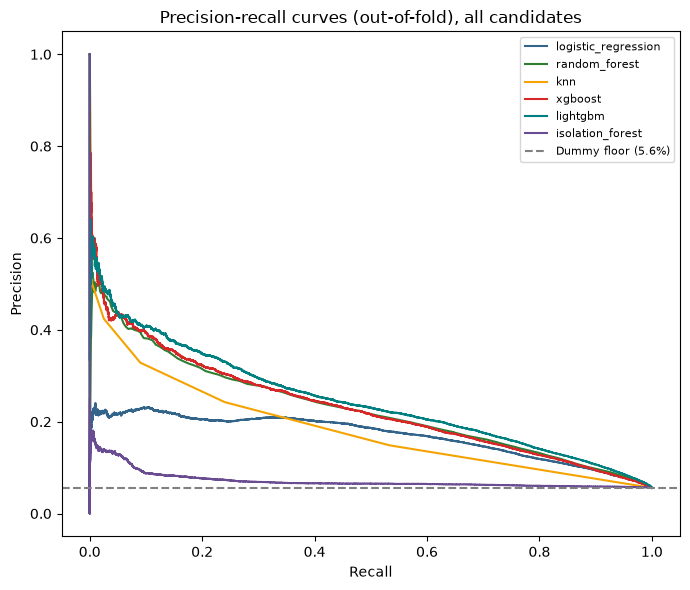

In [140]:
y_values = y.to_numpy()

oof_probas = {}
for name, pipeline in pipelines.items():
    oof_probas[name] = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
    print(f"done: {name}")

fig, ax = plt.subplots(figsize=(7, 6))
colors = {"logistic_regression": "#33658A", "random_forest": "#2E7D32", "knn": "#F4A300",
          "xgboost": "#D62828", "lightgbm": "#008080", "isolation_forest": "#6A4C93"}
for name, oof_proba in oof_probas.items():
    precisions, recalls, _ = precision_recall_curve(y_values, oof_proba)
    ax.plot(recalls, precisions, label=name, color=colors.get(name))
ax.axhline(base_rate, linestyle="--", color="grey", label=f"Dummy floor ({base_rate:.1%})")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves (out-of-fold), all candidates")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [141]:
# Build the summary from the current model outputs so the table cannot become stale.
results_table = model_comparison[["average_precision_mean", "roc_auc_mean"]].rename(columns={
    "average_precision_mean": "PR-AUC",
    "roc_auc_mean": "ROC-AUC",
})
display(results_table.round({"PR-AUC": 3, "ROC-AUC": 3}))

,PR-AUC,ROC-AUC
lightgbm,0.247,0.831
xgboost,0.232,0.812
random_forest,0.227,0.816
logistic_regression,0.170,0.795
knn,0.139,0.687
isolation_forest,0.072,0.560
"dummy (from 02, not re-run)",0.056,0.502


## Interpretation

- Use the generated table to identify the best ranking model by PR-AUC.
- Compare the precision-recall curves as well as the single summary metrics; a model should not be called the winner from one rounded value alone.
- LightGBM, Random Forest, and XGBoost use the same one-hot preprocessing in this comparison. LightGBM's native categorical handling is not tested here.
- KNN has no `class_weight` option, while Isolation Forest is unsupervised; interpret their results as different modelling bets, not like-for-like supervised baselines.
- The external Zindi reference is context only; the model choice for this project must follow the current table and error analysis.

### Next steps

- Tune the strongest current candidate after error analysis; if LightGBM leads the generated table, start there.
  `GridSearchCV`/`RandomizedSearchCV` (or Optuna, as the real 4th-place solution used) against
  PR-AUC, same CV scheme.
- **Try LightGBM's native categorical handling** (pass `region`/`disrict`/`client_catg` as
  categorical dtype instead of one-hot) as a cheap follow-up variant if LightGBM leads the current comparison.
- Keep Random Forest and XGBoost as references and revisit them only if the current results or error analysis justify it.
- **Retire KNN and Isolation Forest as primary candidates**, as before.
- **Error analysis next, before tuning** -- see the discussion with Sean and Roy on sequencing:
  cheap to do (reuses the out-of-fold predictions already computed above), and its findings
  (systematic misses, segment weaknesses, whether models' errors overlap) should inform *what*
  gets tuned and whether an ensemble is worth trying, rather than tuning blind.
- **Feature optimization / imbalance gates are still not triggered** -- no evidence yet that
  Lasso/PCA or SMOTE would beat what the family change to LightGBM already delivered.